<a href="https://colab.research.google.com/github/GimenesPaula/GimenesPaula/blob/main/Processamento_de_Imagem_Mecha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
#Importar Bibliotecas
import cv2
import numpy as np
import pandas as pd
from google.colab.patches import cv2_imshow
from google.colab import files, drive
from skimage.metrics import structural_similarity as compare_ssim
from PIL import Image
import matplotlib.pyplot as plt
import os

In [6]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Função para carregar imagens
def carregar_imagens():
    uploaded = files.upload()  # Permite ao usuário fazer upload de imagens
    imagens = []
    nomes = []
    for nome_arquivo in uploaded.keys():
        img = cv2.imread(nome_arquivo)
        if img is not None:
            imagens.append(img)
            nomes.append(nome_arquivo)
    return imagens, nomes

In [8]:
# Carregar imagens
imagens, nomes = carregar_imagens()

Saving 12.JPG to 12.JPG
Saving 13.JPG to 13.JPG
Saving 14.JPG to 14.JPG
Saving 5.JPG to 5.JPG


In [37]:
# Função para exibir imagens em uma grade
def exibir_imagens_em_grade(imagens, titulos=None, max_colunas=4):
    num_imagens = len(imagens)
    num_linhas = -(-num_imagens // max_colunas)  # Calcula o número de linhas usando divisão inteira arredondada para cima

    plt.figure(figsize=(15, 5 * num_linhas))  # Ajusta o tamanho da figura

    for i, img in enumerate(imagens):
        plt.subplot(num_linhas, max_colunas, i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Converte BGR para RGB
        if titulos:
            plt.title(titulos[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

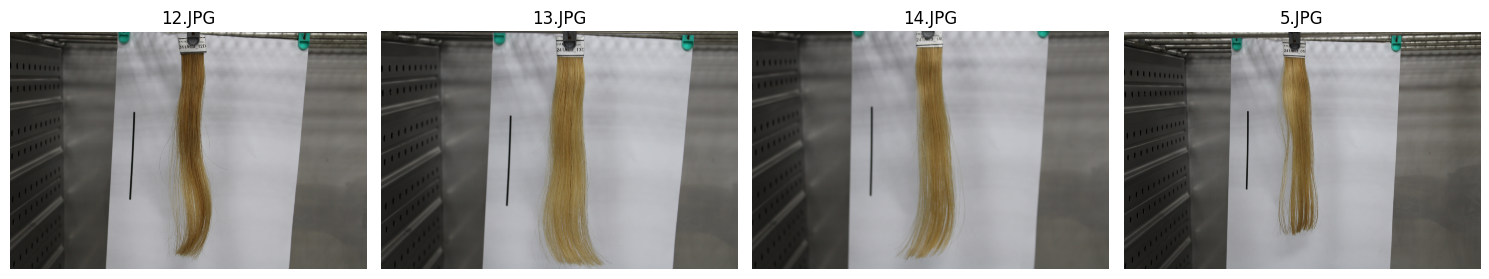

In [38]:
exibir_imagens_em_grade(imagens, nomes)

In [39]:
# Função para detectar a mecha de cabelo e calcular a área
def detectar_mecha_e_calcular_area(imagem):
    # Converter para o espaço de cores HSV
    hsv = cv2.cvtColor(imagem, cv2.COLOR_BGR2HSV)

    # Intervalos de cores para a mecha de cabelo
    intervalos = {
        "amarelo": (np.array([20, 50, 50]), np.array([40, 255, 255])),
        "castanho": (np.array([10, 20, 20]), np.array([20, 200, 200]))
    }

    # Criar máscaras combinadas para amarelo e castanho
    mask = sum(cv2.inRange(hsv, *intervalo) for intervalo in intervalos.values())

    # Operações morfológicas para limpar a máscara
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Encontrar contornos na máscara
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print("Nenhum contorno encontrado!")
        return imagem, None, 0, 0

    # Selecionar o maior contorno
    maior_contorno = max(contours, key=cv2.contourArea)
    area_mecha = cv2.contourArea(maior_contorno)

    # Desenhar o contorno na imagem
    imagem_com_contorno = imagem.copy()
    cv2.drawContours(imagem_com_contorno, [maior_contorno], -1, (0, 255, 0), 2)

    # Detectar a linha preta para calcular a área relativa
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 50]))
    contours_black, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours_black:
        print("Linha preta não encontrada!")
        return imagem_com_contorno, maior_contorno, area_mecha, 0

    # Selecionar o maior contorno da linha preta
    linha_preta = max(contours_black, key=cv2.contourArea)
    area_linha_preta = cv2.contourArea(linha_preta)

    # Calcular a área relativa
    area_relativa = area_mecha / area_linha_preta if area_linha_preta > 0 else 0

    return imagem_com_contorno, maior_contorno, area_mecha, area_relativa

In [47]:
# Função para exibir a área interna de um contorno
def exibir_area_interna(imagem, contorno):
    # Criar uma máscara vazia
    mask = np.zeros(imagem.shape[:2], dtype=np.uint8)

    # Preencher o contorno na máscara
    if contorno is not None:
        cv2.drawContours(mask, [contorno], -1, 255, thickness=cv2.FILLED)

    # Aplicar a máscara na imagem original
    area_interna = cv2.bitwise_and(imagem, imagem, mask=mask)
    return area_interna

In [52]:
# Processar cada imagem
def processar_e_exibir_imagens(imagens, nomes, max_colunas=4):
    imagens_com_contorno = []
    titulos = []
    resultados = []  # Lista para armazenar os dados para o Excel

    for i, img in enumerate(imagens):
        # Detectar a mecha e calcular a área
        imagem_com_contorno, maior_contorno, area_mecha, area_relativa = detectar_mecha_e_calcular_area(img)

        # Adicionar a imagem processada à lista
        imagens_com_contorno.append(imagem_com_contorno)
        titulos.append(f"{nomes[i]}\nÁrea: {area_mecha:.2f}\nRelativa: {area_relativa:.2f}")

        # Adicionar os resultados à lista
        resultados.append({
            "Nome": nomes[i],
            "Área da Mecha": round(area_mecha, 2),
            "Área Relativa": round(area_relativa, 2)
        })

    # Criar um DataFrame do pandas com os resultados
    df = pd.DataFrame(resultados)

    # Salvar o DataFrame em um arquivo Excel
    df.to_excel("Resultado Frizz.xlsx", index=False)

    print("Resultados salvos no arquivo: 'Resultado Frizz.xlsx'")

    # Exibir todas as imagens processadas em uma grade
    exibir_imagens_em_grade(imagens_com_contorno, titulos, max_colunas)

Resultados salvos no arquivo: 'Resultado Frizz.xlsx'


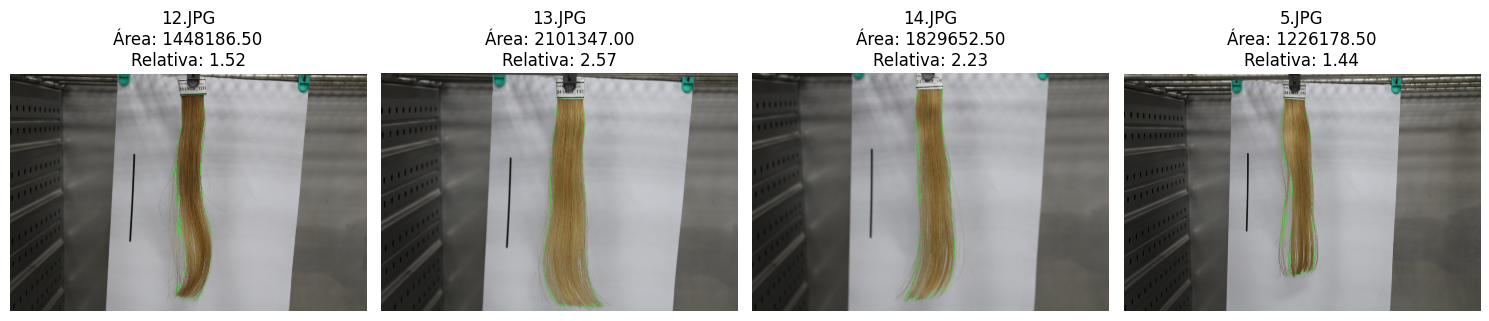

In [53]:
# Chamar a função para processar e exibir as imagens
processar_e_exibir_imagens(imagens, nomes)